# Import libraries

In [1]:
!pip install -q torchinfo

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchinfo import summary

import random
import numpy as np
import pandas as pd
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    PreTrainedModel,
    PretrainedConfig,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    PreTrainedTokenizerFast,
    EarlyStoppingCallback,
    pipeline
)
from transformers.modeling_outputs import SequenceClassifierOutput

from tokenizers import Tokenizer, models, trainers, pre_tokenizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

from datasets import load_dataset

In [3]:
IGNORE_INDEX = -100
SEED = 42
MAX_RNN_LEN = 128
MAX_BERT_LEN = 512

In [4]:
def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)

	torch.manual_seed(seed)

	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass

set_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Download dataset

In [5]:
!gdown 1o09HEkDBBEjsW3gN76vDYfCAKiCqpcpg
!unzip /content/financial_sentiment.zip
!rm -rf /content/financial_sentiment.zip

Downloading...
From: https://drive.google.com/uc?id=1o09HEkDBBEjsW3gN76vDYfCAKiCqpcpg
To: /content/financial_sentiment.zip
100% 925k/925k [00:00<00:00, 67.2MB/s]
Archive:  /content/financial_sentiment.zip
  inflating: FinancialPhraseBank/License.txt  
  inflating: FinancialPhraseBank/README.txt  
  inflating: FinancialPhraseBank/Sentences_50Agree.txt  
  inflating: FinancialPhraseBank/Sentences_66Agree.txt  
  inflating: FinancialPhraseBank/Sentences_75Agree.txt  
  inflating: FinancialPhraseBank/Sentences_AllAgree.txt  
  inflating: all-data.csv            


In [6]:
data_path = '/content/all-data.csv'
headers = ['sentiment', 'content']

df = pd.read_csv(
  data_path,
  names=headers,
  encoding='ISO-8859-1'
)
df

,sentiment,content
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...
...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4844,negative,Net sales of the Paper segment decreased to EU...


In [7]:
classes_lst = df['sentiment'].unique()
n_classes = len(classes_lst)
classes_lst

array(['neutral', 'negative', 'positive'], dtype=object)

In [8]:
label2id = {
    class_name: idx
    for idx, class_name in enumerate(classes_lst)
}

id2label = {
    idx: class_name
    for idx, class_name in enumerate(classes_lst)
}

In [9]:
df['sentiment'] = df['sentiment'].apply(lambda x: label2id[x])

In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=SEED,
    stratify=df['sentiment']
 )
eval_df, test_df = train_test_split(
    temp_df,
    test_size=1/3,
    random_state=SEED,
    stratify=temp_df['sentiment']
)

--- Train Dataset Statistics ---
Mean: 127.38
Max: 315
p95: 232.00
p99: 273.18

--- Eval Dataset Statistics ---
Mean: 128.86
Max: 301
p95: 232.60
p99: 274.96

--- Test Dataset Statistics ---
Mean: 131.92
Max: 306
p95: 244.80
p99: 289.32



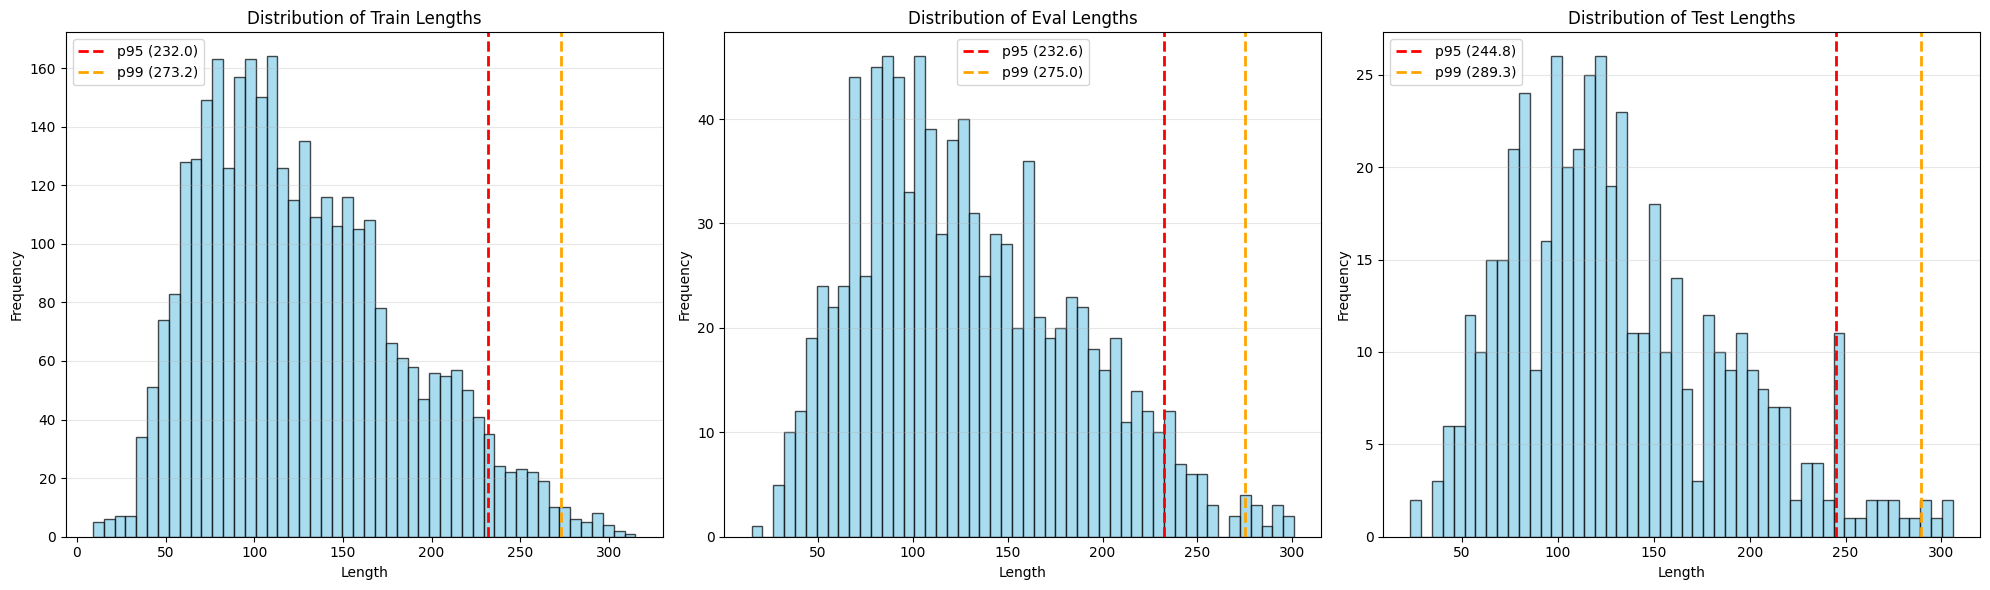

In [11]:
# Define the datasets to process
datasets = {
    'Train': train_df,
    'Eval': eval_df,
    'Test': test_df
}

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, current_df) in enumerate(datasets.items()):
    # Calculate sentence lengths
    lengths = current_df['content'].str.len()

    # Calculate statistics
    mean_val = lengths.mean()
    max_val = lengths.max()
    p95 = np.percentile(lengths, 95)
    p99 = np.percentile(lengths, 99)

    # Print statistics
    print(f"--- {name} Dataset Statistics ---")
    print(f"Mean: {mean_val:.2f}")
    print(f"Max: {max_val}")
    print(f"p95: {p95:.2f}")
    print(f"p99: {p99:.2f}\n")

    # Plot histogram on the corresponding axis
    ax = axes[i]
    ax.hist(lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'p95 ({p95:.1f})')
    ax.axvline(p99, color='orange', linestyle='--', linewidth=2, label=f'p99 ({p99:.1f})')

    ax.set_title(f'Distribution of {name} Lengths')
    ax.set_xlabel('Length')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

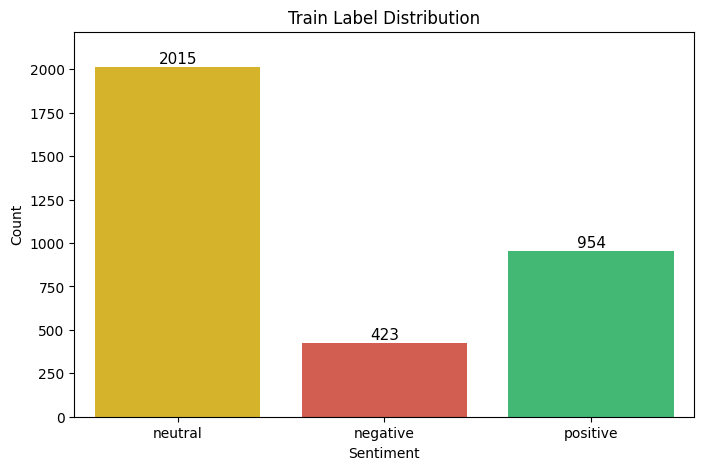

In [12]:
labels = np.array(train_df["sentiment"])

unique, counts = np.unique(labels, return_counts=True)

# Using the existing id2label dictionary
labels_str = [id2label[int(l)] for l in unique]
palette = {
    "negative": "#e74c3c",
    "neutral": "#f1c40f",
    "positive": "#2ecc71"
}

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels_str, y=counts, hue=labels_str, palette=palette, dodge=False, legend=False)

plt.title("Train Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, str(v), ha='center', fontsize=11)

plt.ylim(0, max(counts)*1.1)
plt.show()

# Utils

In [13]:
class FinancialNews(Dataset):
    def __init__(self, X, y, tokenizer, max_seq_len):
        self.texts = X
        self.labels = y
        self.tokenizer = tokenizer
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_seq_len,
            padding=False,
        )

        item = {key: torch.tensor(val, dtype=torch.long)
                for key, val in encoding.items()}

        item["labels"] = torch.tensor(label, dtype=torch.long)

        return item

In [14]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [15]:
def evaluate_model(trainer, eval_dataset, split_name="test", model_name="RNN"):
    predictions, labels, metrics = trainer.predict(eval_dataset)
    preds = np.argmax(predictions, axis=1)

    target_names = [id2label[i] for i in range(len(id2label))]

    print(f"Evaluation on {split_name} set using {model_name}")
    print("Classification Report:")
    print(classification_report(
        labels,
        preds,
        target_names=target_names,
        zero_division=0
    ))

    acc = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [16]:
def plot_loss_curves(history, title='Training and Validation Loss'):
    # Keep only full-epoch logs to align train/eval points cleanly.
    train_epoch_loss = {}
    eval_epoch_loss = {}

    for log in history:
        epoch = log.get('epoch')
        if epoch is None:
            continue

        epoch_float = float(epoch)
        epoch_int = int(round(epoch_float))

        if epoch_int < 1 or abs(epoch_float - epoch_int) > 1e-8:
            continue

        if 'loss' in log and 'eval_loss' not in log:
            train_epoch_loss[epoch_int] = log['loss']
        if 'eval_loss' in log:
            eval_epoch_loss[epoch_int] = log['eval_loss']

    epochs = sorted(set(train_epoch_loss.keys()) & set(eval_epoch_loss.keys()))
    train_loss = [train_epoch_loss[e] for e in epochs]
    eval_loss = [eval_epoch_loss[e] for e in epochs]

    if not epochs:
        raise ValueError('No aligned full-epoch train/eval loss points were found in trainer.state.log_history.')

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'b', label='Training loss')
    plt.plot(epochs, eval_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [17]:
def save_local_checkpoint(model, model_name, base_dir='./saved_models', tokenizer=None):
    """Save model locally for later inference without pushing to Hub."""
    save_dir = Path(base_dir) / model_name
    save_dir.mkdir(parents=True, exist_ok=True)

    if hasattr(model, 'save_pretrained'):
        model.save_pretrained(save_dir)
        if tokenizer is not None and hasattr(tokenizer, 'save_pretrained'):
            tokenizer.save_pretrained(save_dir)
        print(f'Saved Hugging Face model to: {save_dir.resolve()}')
        return str(save_dir)

    torch.save(model.state_dict(), save_dir / 'model_state_dict.pt')
    print(f'Saved PyTorch state_dict to: {(save_dir / "model_state_dict.pt").resolve()}')
    return str(save_dir)

In [18]:
sample_df = test_df.sample(n=10, random_state=SEED).reset_index(drop=True)
texts = sample_df["content"].tolist()
sample_df["true_label"] = sample_df["sentiment"].map(id2label)

# RNN-based model

## Build tokenizer

In [19]:
tokenizer_dir = './financial_bpe_tokenizer'
os.makedirs(tokenizer_dir, exist_ok=True)

# Initialize BPE tokenizer with BERT-style subword prefix
raw_tokenizer = Tokenizer(models.BPE(unk_token='<unk>', continuing_subword_prefix='##'))
raw_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

bpe_trainer = trainers.BpeTrainer(
    vocab_size=15000,
    special_tokens=['<pad>', '<unk>'],
    continuing_subword_prefix='##'
)

# Train from the content iterator
raw_tokenizer.train_from_iterator(train_df['content'].tolist(), trainer=bpe_trainer)
raw_tokenizer.save(f'{tokenizer_dir}/tokenizer.json')

# Wrap with Transformers for use in model training
hf_fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=f'{tokenizer_dir}/tokenizer.json',
    unk_token='<unk>',
    pad_token='<pad>'
)
hf_fast_tokenizer.save_pretrained(tokenizer_dir)

rnn_tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir, use_fast=True)
vocab_size = rnn_tokenizer.vocab_size
pad_token_id = rnn_tokenizer.pad_token_id

In [20]:
vocab_size

15000

## Prepare dataset for training

In [21]:
rnn_train_dataset = FinancialNews(
    train_df['content'].tolist(),
    train_df['sentiment'].tolist(),
    tokenizer=rnn_tokenizer,
    max_seq_len=MAX_RNN_LEN,
)
rnn_eval_dataset = FinancialNews(
    eval_df['content'].tolist(),
    eval_df['sentiment'].tolist(),
    tokenizer=rnn_tokenizer,
    max_seq_len=MAX_RNN_LEN,
)
rnn_test_dataset = FinancialNews(
    test_df['content'].tolist(),
    test_df['sentiment'].tolist(),
    tokenizer=rnn_tokenizer,
    max_seq_len=MAX_RNN_LEN,
)

In [22]:
print(f'Train size: {len(rnn_train_dataset)}, Eval size: {len(rnn_eval_dataset)}, Test size: {len(rnn_test_dataset)}')

Train size: 3392, Eval size: 969, Test size: 485


## RNN

### Model definition

In [23]:
class RNNSequenceClassifierConfig(PretrainedConfig):
    model_type = "rnn-sequence-classifier"

    def __init__(
        self,
        vocab_size=5000,
        embedding_dim=128,
        hidden_dim=256,
        num_labels=3,
        num_layers=2,
        dropout=0.3,
        fc_dim=128,
        pad_token_id=0,
        id2label=None,
        label2id=None,
        **kwargs
    ):
        super().__init__(
            pad_token_id=pad_token_id,
            id2label=id2label,
            label2id=label2id,
            **kwargs
        )

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_labels = num_labels
        self.num_layers = num_layers
        self.dropout = dropout
        self.fc_dim = fc_dim


In [24]:
class RNNForSequenceClassification(PreTrainedModel):
    config_class = RNNSequenceClassifierConfig

    def __init__(self, config):
        super().__init__(config)

        self.embedding = nn.Embedding(
            config.vocab_size,
            config.embedding_dim,
            padding_idx=config.pad_token_id
        )

        self.rnn = nn.RNN(
            input_size=config.embedding_dim,
            hidden_size=config.hidden_dim,
            num_layers=config.num_layers,
            batch_first=True
        )

        self.norm = nn.LayerNorm(config.hidden_dim)
        self.dropout = nn.Dropout(config.dropout)

        self.classifier = nn.Sequential(
            nn.Linear(config.hidden_dim, config.fc_dim),
            nn.SiLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.fc_dim, config.num_labels)
        )

        self.post_init()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        **kwargs
    ):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        outputs, _ = self.rnn(x)

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (outputs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-8)
        else:
            pooled = outputs.mean(dim=1)

        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)

        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits
        )

In [25]:
import sys
from pathlib import Path

dummy_file = "/tmp/notebook.py"
Path(dummy_file).write_text("# dummy notebook file\n", encoding="utf-8")

sys.modules["__main__"].__file__ = dummy_file

In [26]:
rnn_config = RNNSequenceClassifierConfig(
    vocab_size=rnn_tokenizer.vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_labels=3,
    num_layers=2,
    dropout=0.3,
    fc_dim=128,
    pad_token_id=rnn_tokenizer.pad_token_id,
    id2label=id2label,
    label2id=label2id
)
rnn_model = RNNForSequenceClassification(rnn_config)

In [27]:
summary(rnn_model, input_size=(1, 10), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
RNNForSequenceClassification             [1, 3]                    --
├─Embedding: 1-1                         [1, 10, 128]              1,920,000
├─Dropout: 1-2                           [1, 10, 128]              --
├─RNN: 1-3                               [1, 10, 256]              230,400
├─LayerNorm: 1-4                         [1, 256]                  512
├─Dropout: 1-5                           [1, 256]                  --
├─Sequential: 1-6                        [1, 3]                    --
│    └─Linear: 2-1                       [1, 128]                  32,896
│    └─SiLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 3]                    387
Total params: 2,184,195
Trainable params: 2,184,195
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.26
Input size (MB): 0.00

### Training

In [28]:
rnn_training_args = TrainingArguments(
    output_dir='rnn_results',
    num_train_epochs=100,
    learning_rate=1e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,

    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    seed=SEED,
)

rnn_trainer = Trainer(
    model=rnn_model,
    args=rnn_training_args,
    train_dataset=rnn_train_dataset,
    eval_dataset=rnn_eval_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=rnn_tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=15)]
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [29]:
rnn_train_result = rnn_trainer.train()
print('Train result:', rnn_train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.086245,1.071881,0.594427,0.198142,0.333333,0.248544
2,1.049411,1.019334,0.594427,0.198142,0.333333,0.248544
3,0.992550,0.963468,0.594427,0.198142,0.333333,0.248544
4,0.949639,0.932559,0.594427,0.198142,0.333333,0.248544
5,0.934666,0.925924,0.594427,0.198142,0.333333,0.248544
6,0.927767,0.924564,0.594427,0.198142,0.333333,0.248544
7,0.927295,0.923162,0.594427,0.198142,0.333333,0.248544
8,0.925150,0.917644,0.594427,0.198142,0.333333,0.248544
9,0.902777,0.854040,0.607843,0.376723,0.349265,0.281812
10,0.805610,0.802450,0.660475,0.412439,0.476443,0.441153


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Train result: TrainOutput(global_step=1377, training_loss=0.34701967628952723, metrics={'train_runtime': 112.0613, 'train_samples_per_second': 3026.916, 'train_steps_per_second': 24.094, 'total_flos': 16687452349440.0, 'train_loss': 0.34701967628952723, 'epoch': 51.0})


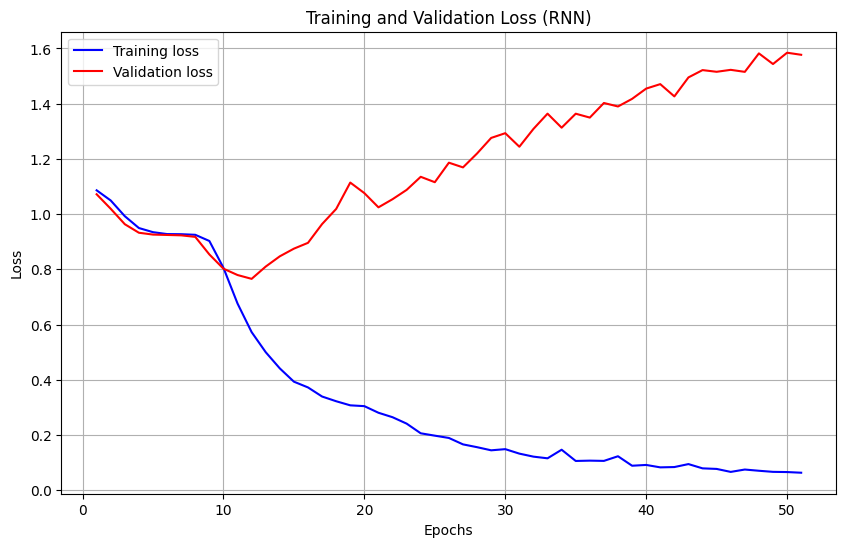

In [30]:
history = rnn_trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (RNN)')

### Evaluate

In [31]:
rnn_result = evaluate_model(rnn_trainer, rnn_test_dataset, split_name="test", model_name="RNN")

Evaluation on test set using RNN
Classification Report:
              precision    recall  f1-score   support

     neutral       0.78      0.76      0.77       288
    negative       0.56      0.47      0.51        60
    positive       0.47      0.53      0.50       137

    accuracy                           0.66       485
   macro avg       0.61      0.59      0.59       485
weighted avg       0.67      0.66      0.66       485

Accuracy: 0.6619
Precision: 0.6056
Recall: 0.5878
F1 Score: 0.5947


### Inference

In [48]:
rnn_pipe = pipeline(
    "text-classification",
    model=rnn_model,
    tokenizer=rnn_tokenizer,
)
preds = rnn_pipe(
    texts,
    truncation=True,
    max_length=MAX_RNN_LEN,
)
rnn_df = sample_df.copy()
rnn_df["pred_label"] = [p["label"] for p in preds]
rnn_df["pred_score"] = [p["score"] for p in preds]
rnn_df[["true_label", "pred_label", "pred_score", "content"]]
display(rnn_df)

The model 'RNNForSequenceClassification' is not supported for text-classification. Supported models are ['PeftModelForSequenceClassification', 'AlbertForSequenceClassification', 'ArceeForSequenceClassification', 'BartForSequenceClassification', 'BertForSequenceClassification', 'BigBirdForSequenceClassification', 'BigBirdPegasusForSequenceClassification', 'BioGptForSequenceClassification', 'BloomForSequenceClassification', 'CamembertForSequenceClassification', 'CanineForSequenceClassification', 'LlamaForSequenceClassification', 'ConvBertForSequenceClassification', 'CTRLForSequenceClassification', 'Data2VecTextForSequenceClassification', 'DebertaForSequenceClassification', 'DebertaV2ForSequenceClassification', 'DeepseekV2ForSequenceClassification', 'DeepseekV3ForSequenceClassification', 'DiffLlamaForSequenceClassification', 'DistilBertForSequenceClassification', 'DogeForSequenceClassification', 'ElectraForSequenceClassification', 'ErnieForSequenceClassification', 'EsmForSequenceClassific

,sentiment,content,true_label,pred_label,pred_score
0,0,"The familiar blue , white , and red HK seal ha...",neutral,positive,0.966317
1,0,Shares will be acquired in accordance with sec...,neutral,neutral,0.997422
2,2,"( ADP News ) - Feb 6 , 2009 - Finnish fishing ...",positive,positive,0.989210
3,2,Stora Enso owns 43 percent of Bergvik and earn...,positive,positive,0.515150
4,0,Le Lay succeeds Walter G++nter and will be bas...,neutral,neutral,0.997895
5,2,The expansion includes the doubling of the flo...,positive,neutral,0.996559
6,0,The company says the measures are no longer ne...,neutral,neutral,0.986898
7,0,The planned ethanol and energy production plan...,neutral,neutral,0.998199
8,0,An estimated 30 pct of mobile calls are made f...,neutral,neutral,0.993334
9,1,Publishing Sweden 's operating loss was EUR 1....,negative,negative,0.735172


## LSTM

### Model definition

In [33]:
class LSTMSequenceClassifierConfig(PretrainedConfig):
    model_type = "lstm-sequence-classifier"

    def __init__(
        self,
        vocab_size=5000,
        embedding_dim=128,
        hidden_dim=256,
        num_labels=3,
        num_layers=2,
        dropout=0.3,
        bidirectional=True,
        fc_dim=128,
        pad_token_id=0,
        id2label=None,
        label2id=None,
        **kwargs
    ):
        super().__init__(
            pad_token_id=pad_token_id,
            id2label=id2label,
            label2id=label2id,
            **kwargs
        )

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_labels = num_labels
        self.num_layers = num_layers
        self.dropout = dropout
        self.bidirectional = bidirectional
        self.fc_dim = fc_dim

In [34]:
class LSTMForSequenceClassification(PreTrainedModel):
    config_class = LSTMSequenceClassifierConfig

    def __init__(self, config):
        super().__init__(config)

        self.embedding = nn.Embedding(
            config.vocab_size,
            config.embedding_dim,
            padding_idx=config.pad_token_id
        )

        rnn_dropout = config.dropout if config.num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=config.embedding_dim,
            hidden_size=config.hidden_dim,
            num_layers=config.num_layers,
            batch_first=True,
            dropout=rnn_dropout,
            bidirectional=config.bidirectional
        )

        hidden_dim = config.hidden_dim * 2 if config.bidirectional else config.hidden_dim

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(config.dropout)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, config.fc_dim),
            nn.SiLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.fc_dim, config.num_labels)
        )

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        outputs, _ = self.lstm(x)

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (outputs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-8)
        else:
            pooled = outputs.mean(dim=1)

        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)

        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

In [35]:
lstm_config = LSTMSequenceClassifierConfig(
    vocab_size=rnn_tokenizer.vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_labels=3,
    num_layers=2,
    dropout=0.3,
    fc_dim=128,
    pad_token_id=rnn_tokenizer.pad_token_id,
    id2label=id2label,
    label2id=label2id
)
lstm_model = LSTMForSequenceClassification(lstm_config)

In [36]:
summary(lstm_model, input_size=(1, 10), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
LSTMForSequenceClassification            [1, 3]                    --
├─Embedding: 1-1                         [1, 10, 128]              1,920,000
├─Dropout: 1-2                           [1, 10, 128]              --
├─LSTM: 1-3                              [1, 10, 512]              2,367,488
├─LayerNorm: 1-4                         [1, 512]                  1,024
├─Dropout: 1-5                           [1, 512]                  --
├─Sequential: 1-6                        [1, 3]                    --
│    └─Linear: 2-1                       [1, 128]                  65,664
│    └─SiLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 3]                    387
Total params: 4,354,563
Trainable params: 4,354,563
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 25.66
Input size (MB):

### Training

In [37]:
lstm_training_args = TrainingArguments(
    output_dir='lstm_results',
    num_train_epochs=100,
    learning_rate=5e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,

    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    seed=SEED,
)

lstm_trainer = Trainer(
    model=lstm_model,
    args=lstm_training_args,
    train_dataset=rnn_train_dataset,
    eval_dataset=rnn_eval_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=rnn_tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=15)]
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [38]:
lstm_train_result = lstm_trainer.train()
print('Train result:', lstm_train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.040564,0.961388,0.594427,0.198142,0.333333,0.248544
2,0.940058,0.929353,0.594427,0.198142,0.333333,0.248544
3,0.934859,0.925232,0.594427,0.198142,0.333333,0.248544
4,0.927316,0.921615,0.594427,0.198142,0.333333,0.248544
5,0.902535,0.829136,0.644995,0.386455,0.396616,0.359576
6,0.705616,0.744595,0.670795,0.416012,0.477703,0.444577
7,0.506570,0.806228,0.669763,0.417065,0.481005,0.446061
8,0.395867,0.883643,0.653251,0.572362,0.470924,0.443523
9,0.311973,1.165613,0.668731,0.642052,0.488551,0.499764
10,0.244636,1.143827,0.680083,0.644219,0.565138,0.589755


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Train result: TrainOutput(global_step=1701, training_loss=0.13183409490703066, metrics={'train_runtime': 220.9351, 'train_samples_per_second': 1535.293, 'train_steps_per_second': 12.221, 'total_flos': 189931439143296.0, 'train_loss': 0.13183409490703066, 'epoch': 63.0})


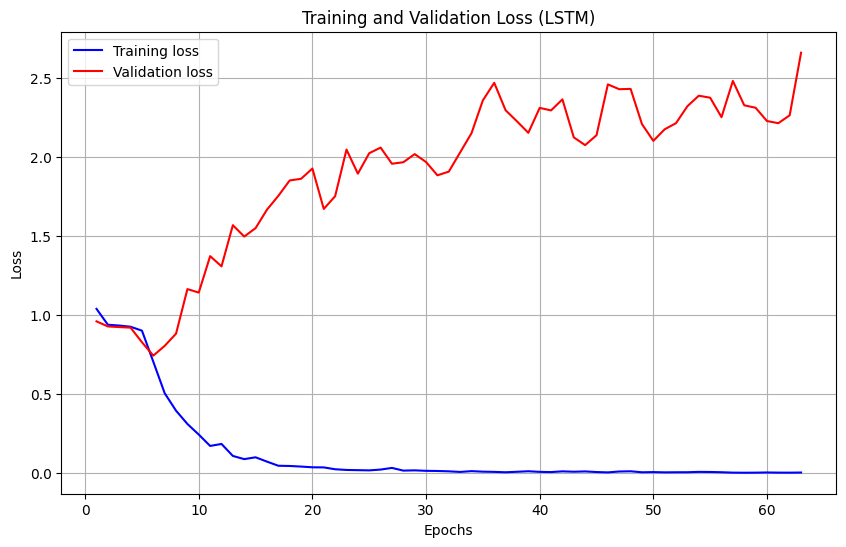

In [39]:
history = lstm_trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (LSTM)')

### Evaluate

In [40]:
lstm_result = evaluate_model(
    lstm_trainer,
    rnn_test_dataset,
    split_name="test",
    model_name="LSTM"
)

Evaluation on test set using LSTM
Classification Report:
              precision    recall  f1-score   support

     neutral       0.75      0.83      0.79       288
    negative       0.61      0.58      0.60        60
    positive       0.56      0.43      0.49       137

    accuracy                           0.69       485
   macro avg       0.64      0.62      0.62       485
weighted avg       0.68      0.69      0.68       485

Accuracy: 0.6887
Precision: 0.6387
Recall: 0.6158
F1 Score: 0.6236


### Inference

In [49]:
lstm_pipe = pipeline(
    "text-classification",
    model=lstm_model,
    tokenizer=rnn_tokenizer,
)
preds = lstm_pipe(
    texts,
    truncation=True,
    max_length=MAX_RNN_LEN,
)
lstm_df = sample_df.copy()
lstm_df["pred_label"] = [p["label"] for p in preds]
lstm_df["pred_score"] = [p["score"] for p in preds]
lstm_df[["true_label", "pred_label", "pred_score", "content"]]
display(lstm_df)

The model 'LSTMForSequenceClassification' is not supported for text-classification. Supported models are ['PeftModelForSequenceClassification', 'AlbertForSequenceClassification', 'ArceeForSequenceClassification', 'BartForSequenceClassification', 'BertForSequenceClassification', 'BigBirdForSequenceClassification', 'BigBirdPegasusForSequenceClassification', 'BioGptForSequenceClassification', 'BloomForSequenceClassification', 'CamembertForSequenceClassification', 'CanineForSequenceClassification', 'LlamaForSequenceClassification', 'ConvBertForSequenceClassification', 'CTRLForSequenceClassification', 'Data2VecTextForSequenceClassification', 'DebertaForSequenceClassification', 'DebertaV2ForSequenceClassification', 'DeepseekV2ForSequenceClassification', 'DeepseekV3ForSequenceClassification', 'DiffLlamaForSequenceClassification', 'DistilBertForSequenceClassification', 'DogeForSequenceClassification', 'ElectraForSequenceClassification', 'ErnieForSequenceClassification', 'EsmForSequenceClassifi

,sentiment,content,true_label,pred_label,pred_score
0,0,"The familiar blue , white , and red HK seal ha...",neutral,positive,0.973571
1,0,Shares will be acquired in accordance with sec...,neutral,neutral,0.999994
2,2,"( ADP News ) - Feb 6 , 2009 - Finnish fishing ...",positive,positive,0.956311
3,2,Stora Enso owns 43 percent of Bergvik and earn...,positive,positive,0.902667
4,0,Le Lay succeeds Walter G++nter and will be bas...,neutral,neutral,0.999996
5,2,The expansion includes the doubling of the flo...,positive,neutral,0.999996
6,0,The company says the measures are no longer ne...,neutral,neutral,0.999996
7,0,The planned ethanol and energy production plan...,neutral,neutral,0.999994
8,0,An estimated 30 pct of mobile calls are made f...,neutral,neutral,0.999995
9,1,Publishing Sweden 's operating loss was EUR 1....,negative,negative,0.999710


## GRU

### Model definition

In [41]:
class GRUSequenceClassifierConfig(PretrainedConfig):
    model_type = "gru-sequence-classifier"

    def __init__(
        self,
        vocab_size=5000,
        embedding_dim=128,
        hidden_dim=256,
        num_labels=3,
        num_layers=2,
        dropout=0.3,
        bidirectional=True,
        fc_dim=128,
        pad_token_id=0,
        id2label=None,
        label2id=None,
        **kwargs
    ):
        super().__init__(
            pad_token_id=pad_token_id,
            id2label=id2label,
            label2id=label2id,
            **kwargs
        )

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_labels = num_labels
        self.num_layers = num_layers
        self.dropout = dropout
        self.bidirectional = bidirectional
        self.fc_dim = fc_dim

In [42]:
class GRUForSequenceClassification(PreTrainedModel):
    config_class = GRUSequenceClassifierConfig

    def __init__(self, config):
        super().__init__(config)

        self.embedding = nn.Embedding(
            config.vocab_size,
            config.embedding_dim,
            padding_idx=config.pad_token_id
        )

        rnn_dropout = config.dropout if config.num_layers > 1 else 0.0

        self.gru = nn.GRU(
            input_size=config.embedding_dim,
            hidden_size=config.hidden_dim,
            num_layers=config.num_layers,
            batch_first=True,
            dropout=rnn_dropout,
            bidirectional=config.bidirectional
        )

        hidden_dim = config.hidden_dim * 2 if config.bidirectional else config.hidden_dim

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(config.dropout)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, config.fc_dim),
            nn.SiLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.fc_dim, config.num_labels)
        )

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        outputs, _ = self.gru(x)

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (outputs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-8)
        else:
            pooled = outputs.mean(dim=1)

        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)

        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

In [43]:
gru_config = GRUSequenceClassifierConfig(
    vocab_size=rnn_tokenizer.vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_labels=3,
    num_layers=2,
    dropout=0.3,
    fc_dim=128,
    pad_token_id=rnn_tokenizer.pad_token_id,
    id2label=id2label,
    label2id=label2id
)
gru_model = GRUForSequenceClassification(gru_config)

### Training

In [44]:
gru_training_args = TrainingArguments(
    output_dir='gru_results',
    num_train_epochs=100,
    learning_rate=5e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,

    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    seed=SEED,
)

gru_trainer = Trainer(
    model=gru_model,
    args=gru_training_args,
    train_dataset=rnn_train_dataset,
    eval_dataset=rnn_eval_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=rnn_tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=15)]
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [45]:
gru_train_result = gru_trainer.train()
print('Train result:', gru_train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.043157,0.958011,0.594427,0.198142,0.333333,0.248544
2,0.938368,0.927590,0.594427,0.198142,0.333333,0.248544
3,0.933687,0.924600,0.594427,0.198142,0.333333,0.248544
4,0.926362,0.914871,0.594427,0.198142,0.333333,0.248544
5,0.851549,0.799181,0.646027,0.412438,0.480630,0.439271
6,0.642654,0.746500,0.672859,0.422015,0.488562,0.451598
7,0.463154,0.850716,0.670795,0.413055,0.473175,0.441028
8,0.363157,1.046365,0.663571,0.404268,0.460069,0.430241
9,0.306637,1.078166,0.662539,0.626726,0.528534,0.536554
10,0.234116,1.168413,0.674923,0.636120,0.557832,0.579722


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Train result: TrainOutput(global_step=1566, training_loss=0.13307285638785377, metrics={'train_runtime': 148.3919, 'train_samples_per_second': 2285.838, 'train_steps_per_second': 18.195, 'total_flos': 132392129849088.0, 'train_loss': 0.13307285638785377, 'epoch': 58.0})


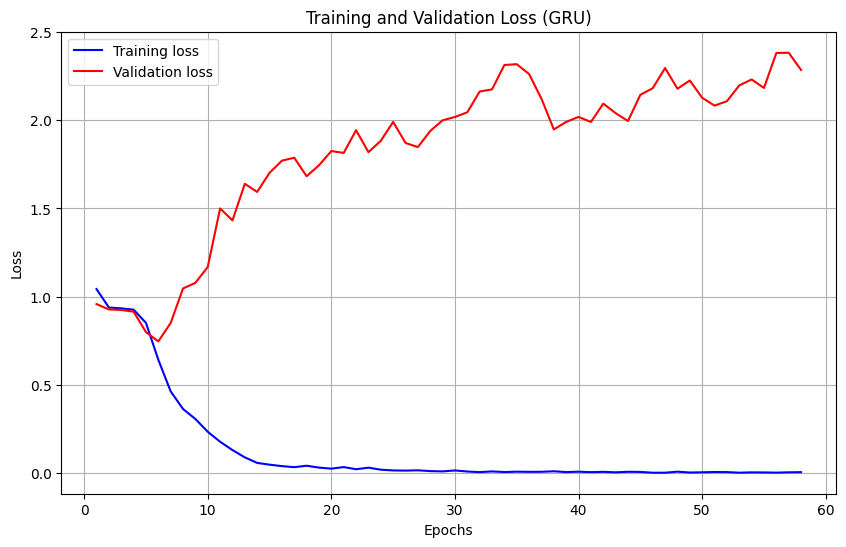

In [46]:
history = gru_trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (GRU)')

### Evaluate

In [47]:
gru_result = evaluate_model(
    gru_trainer,
    rnn_test_dataset,
    split_name="test",
    model_name="GRU"
)

Evaluation on test set using GRU
Classification Report:
              precision    recall  f1-score   support

     neutral       0.76      0.76      0.76       288
    negative       0.52      0.60      0.56        60
    positive       0.55      0.53      0.54       137

    accuracy                           0.67       485
   macro avg       0.61      0.63      0.62       485
weighted avg       0.67      0.67      0.67       485

Accuracy: 0.6722
Precision: 0.6121
Recall: 0.6275
F1 Score: 0.6188


### Inference

In [50]:
gru_pipe = pipeline(
    "text-classification",
    model=gru_model,
    tokenizer=rnn_tokenizer,
)
preds = gru_pipe(
    texts,
    truncation=True,
    max_length=MAX_RNN_LEN,
)
gru_df = sample_df.copy()
gru_df["pred_label"] = [p["label"] for p in preds]
gru_df["pred_score"] = [p["score"] for p in preds]
gru_df[["true_label", "pred_label", "pred_score", "content"]]
display(gru_df)

The model 'GRUForSequenceClassification' is not supported for text-classification. Supported models are ['PeftModelForSequenceClassification', 'AlbertForSequenceClassification', 'ArceeForSequenceClassification', 'BartForSequenceClassification', 'BertForSequenceClassification', 'BigBirdForSequenceClassification', 'BigBirdPegasusForSequenceClassification', 'BioGptForSequenceClassification', 'BloomForSequenceClassification', 'CamembertForSequenceClassification', 'CanineForSequenceClassification', 'LlamaForSequenceClassification', 'ConvBertForSequenceClassification', 'CTRLForSequenceClassification', 'Data2VecTextForSequenceClassification', 'DebertaForSequenceClassification', 'DebertaV2ForSequenceClassification', 'DeepseekV2ForSequenceClassification', 'DeepseekV3ForSequenceClassification', 'DiffLlamaForSequenceClassification', 'DistilBertForSequenceClassification', 'DogeForSequenceClassification', 'ElectraForSequenceClassification', 'ErnieForSequenceClassification', 'EsmForSequenceClassific

,sentiment,content,true_label,pred_label,pred_score
0,0,"The familiar blue , white , and red HK seal ha...",neutral,positive,0.999750
1,0,Shares will be acquired in accordance with sec...,neutral,neutral,0.999987
2,2,"( ADP News ) - Feb 6 , 2009 - Finnish fishing ...",positive,positive,0.910733
3,2,Stora Enso owns 43 percent of Bergvik and earn...,positive,positive,0.998168
4,0,Le Lay succeeds Walter G++nter and will be bas...,neutral,neutral,0.999986
5,2,The expansion includes the doubling of the flo...,positive,neutral,0.999985
6,0,The company says the measures are no longer ne...,neutral,neutral,0.999987
7,0,The planned ethanol and energy production plan...,neutral,neutral,0.999989
8,0,An estimated 30 pct of mobile calls are made f...,neutral,neutral,0.999976
9,1,Publishing Sweden 's operating loss was EUR 1....,negative,negative,0.999820


# BERT-based model

## MiniLM

### Model defination & Tokenizer

In [51]:
minilm_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L12-v2")
minilm_model = AutoModelForSequenceClassification.from_pretrained(
    "sentence-transformers/all-MiniLM-L12-v2",
    num_labels=n_classes,
    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [52]:
minilm_train_dataset = FinancialNews(
    train_df['content'].tolist(),
    train_df['sentiment'].tolist(),
    tokenizer=minilm_tokenizer,
    max_seq_len=MAX_BERT_LEN,
)
minilm_eval_dataset = FinancialNews(
    eval_df['content'].tolist(),
    eval_df['sentiment'].tolist(),
    tokenizer=minilm_tokenizer,
    max_seq_len=MAX_BERT_LEN,
)
minilm_test_dataset = FinancialNews(
    test_df['content'].tolist(),
    test_df['sentiment'].tolist(),
    tokenizer=minilm_tokenizer,
    max_seq_len=MAX_BERT_LEN,
)

### Training

In [53]:
minilm_training_args = TrainingArguments(
    output_dir='minilm_results',
    num_train_epochs=10,
    learning_rate=1e-4,

    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    seed=SEED,
)

minilm_trainer = Trainer(
    model=minilm_model,
    args=minilm_training_args,
    train_dataset=minilm_train_dataset,
    eval_dataset=minilm_eval_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=minilm_tokenizer),
    compute_metrics=compute_metrics,
)

In [54]:
minilm_train_result = minilm_trainer.train()
print('Train result:', minilm_train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.653186,0.432636,0.835913,0.830556,0.787665,0.806607
2,0.364613,0.418819,0.835913,0.806072,0.823015,0.806616
3,0.238627,0.409023,0.849329,0.824143,0.833004,0.827704
4,0.157067,0.489088,0.841073,0.806978,0.844490,0.821823
5,0.100900,0.640707,0.825593,0.797567,0.851508,0.818593
6,0.069332,0.565305,0.853457,0.828740,0.842319,0.831983
7,0.045254,0.633220,0.844169,0.819484,0.844576,0.831054
8,0.037786,0.627705,0.853457,0.833609,0.835084,0.833499
9,0.027052,0.625088,0.850361,0.827027,0.838346,0.831795
10,0.019857,0.637970,0.851393,0.831798,0.845629,0.838412


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Train result: TrainOutput(global_step=530, training_loss=0.17220834426160128, metrics={'train_runtime': 244.081, 'train_samples_per_second': 138.97, 'train_steps_per_second': 2.171, 'total_flos': 313255158233472.0, 'train_loss': 0.17220834426160128, 'epoch': 10.0})


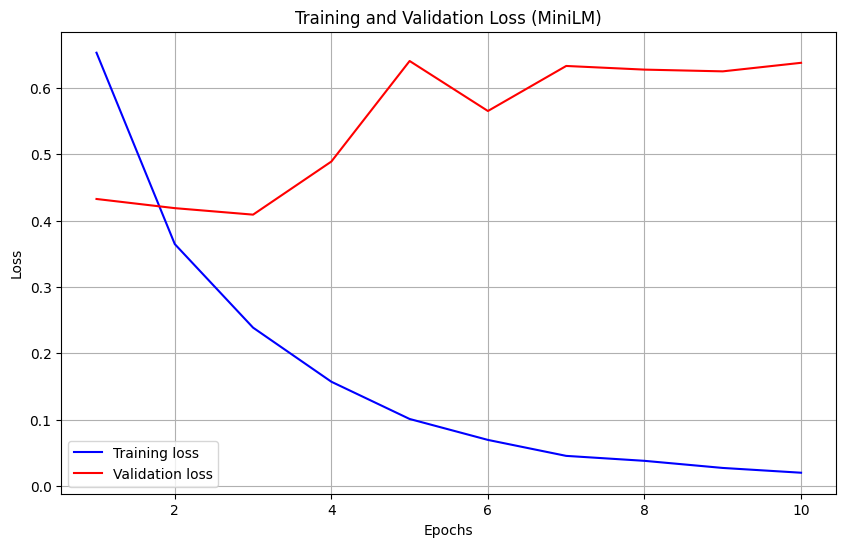

In [55]:
history = minilm_trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (MiniLM)')

### Evaluate

In [60]:
minilm_result = evaluate_model(
    minilm_trainer,
    minilm_test_dataset,
    split_name="test",
    model_name="MiniLM"
)

Evaluation on test set using MiniLM
Classification Report:
              precision    recall  f1-score   support

     neutral       0.86      0.85      0.85       288
    negative       0.74      0.75      0.74        60
    positive       0.74      0.77      0.76       137

    accuracy                           0.81       485
   macro avg       0.78      0.79      0.78       485
weighted avg       0.81      0.81      0.81       485

Accuracy: 0.8124
Precision: 0.7815
Recall: 0.7879
F1 Score: 0.7846


### Inference

In [57]:
minilm_pipe = pipeline(
    "text-classification",
    model=minilm_model,
    tokenizer=minilm_tokenizer,
)
preds = minilm_pipe(
    texts,
    truncation=True,
    max_length=MAX_BERT_LEN,
)
minilm_df = sample_df.copy()
minilm_df["pred_label"] = [p["label"] for p in preds]
minilm_df["pred_score"] = [p["score"] for p in preds]
minilm_df[["true_label", "pred_label", "pred_score", "content"]]
display(minilm_df)

,sentiment,content,true_label,pred_label,pred_score
0,0,"The familiar blue , white , and red HK seal ha...",neutral,positive,0.915293
1,0,Shares will be acquired in accordance with sec...,neutral,neutral,0.997449
2,2,"( ADP News ) - Feb 6 , 2009 - Finnish fishing ...",positive,positive,0.995610
3,2,Stora Enso owns 43 percent of Bergvik and earn...,positive,neutral,0.994323
4,0,Le Lay succeeds Walter G++nter and will be bas...,neutral,neutral,0.997121
5,2,The expansion includes the doubling of the flo...,positive,neutral,0.860510
6,0,The company says the measures are no longer ne...,neutral,neutral,0.997387
7,0,The planned ethanol and energy production plan...,neutral,neutral,0.997461
8,0,An estimated 30 pct of mobile calls are made f...,neutral,neutral,0.995975
9,1,Publishing Sweden 's operating loss was EUR 1....,negative,negative,0.990209


# Benchmark

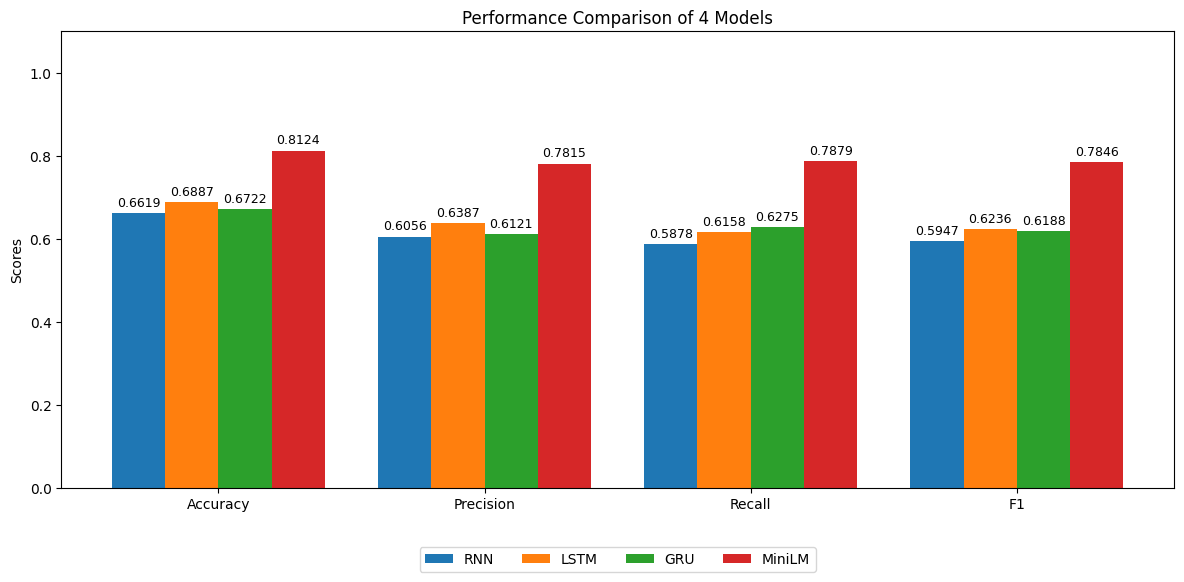

In [69]:
# Prepare data
models = ['RNN', 'LSTM', 'GRU', 'MiniLM']
results = [rnn_result, lstm_result, gru_result, minilm_result]
metrics = ['accuracy', 'precision', 'recall', 'f1']

x = np.arange(len(metrics))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model_name, res) in enumerate(zip(models, results)):
    values = [res[m] for m in metrics]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, values, width, label=model_name)

    # Add text annotations on top of the bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontsize=9)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Performance Comparison of 4 Models')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1.1)  # Set y-limit slightly above 1 to make room for text
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.tight_layout()
plt.show()